In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("✅ Dataset loaded")

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1
)

test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"🔥 Test Accuracy: {test_acc * 100:.2f}%")

model.save("mnist_cnn.h5")
print("💾 Model saved as mnist_cnn.h5")

model = load_model("mnist_cnn.h5")
print("✅ Model loaded successfully")

✅ Dataset loaded


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - accuracy: 0.9317 - loss: 0.2296 - val_accuracy: 0.9793 - val_loss: 0.0674
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.9812 - loss: 0.0617 - val_accuracy: 0.9870 - val_loss: 0.0472
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.9866 - loss: 0.0431 - val_accuracy: 0.9865 - val_loss: 0.0473
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.9889 - loss: 0.0342 - val_accuracy: 0.9878 - val_loss: 0.0402
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.9914 - loss: 0.0259 - val_accuracy: 0.9883 - val_loss: 0.0393
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9875 - loss: 0.0360


🔥 Test Accuracy: 98.75%
💾 Model saved as mnist_cnn.h5


✅ Model loaded successfully


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
🎯 Predicted Digit: 0


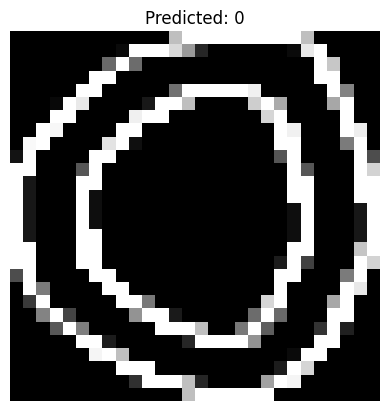

In [ ]:
image_path = "digit4.png"

if not os.path.exists(image_path):
    print("❌ digit.png not found in folder")
else:
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print("❌ Failed to load image")
    else:

        img = cv2.resize(img, (200, 200))

        img = cv2.GaussianBlur(img, (5,5), 0)

        img = cv2.adaptiveThreshold(
            img, 255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY_INV,
            11, 2
        )

        contours, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        c = max(contours, key=cv2.contourArea)
        x,y,w,h = cv2.boundingRect(c)
        img = img[y:y+h, x:x+w]

        img = cv2.resize(img, (28, 28))

        img = img / 255.0

        img = img.reshape(1, 28, 28, 1)
        prediction = model.predict(img)
        predicted_digit = np.argmax(prediction)

        print("🎯 Predicted Digit:", predicted_digit)

        plt.imshow(img.reshape(28,28), cmap='gray')
        plt.title(f"Predicted: {predicted_digit}")
        plt.axis("off")
        plt.show()

# ===============================
# END OF FILE
# ===============================
